# Classification

In this notebook, I train a classifier on the ticket groups defined in `1. Exploration.ipynb`, so that future tickets can be classified automatically.

## Plan

- Load the exploration artifacts: the ticket groups (`ticket_groups.json`), the cleaned tickets (`cleaned_tickets.pkl`) and their `multilingual-e5-large` embeddings. The groups are the HDBSCAN clusters *after* label spreading reclaimed part of the noise bucket, so `Other` is smaller than the raw noise share.
- Train a multinomial logistic regression on the groups, except `Other` since it is the HDBSCAN noise cluster.
- Add a rejection rule: when the model is not confident enough, classify the ticket to `Other` for a human instead of forcing a class. The `Other` tickets are used to calibrate that threshold.
- Save the model, the threshold and an inference function that cleans and embeds a new ticket the same way the exploration notebook did.

## Packages and settings

In [1]:
import hashlib
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss

import matplotlib.pyplot as plt

from ticket_cleaning import clean_ticket

g:\Projects\Voll Technical Challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# Display
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)
DISPLAY_STRING_LIMIT = 5000

SEED = 42
CLEANED_TICKETS_PATH = Path("dataset/cleaned_tickets.pkl")
TICKET_GROUPS_PATH = Path("dataset/ticket_groups.json")
EMBEDDINGS_DIR = Path("dataset/embeddings")
MODEL_PATH = Path("models/ticket_classifier.joblib")
OTHER_LABEL = "Other"

# Same encoder, prefix and batch size as the exploration notebook: the cache key below depends on them,
# and new tickets must be embedded exactly the same way at inference.
EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
EMBEDDING_PREFIX = "query: "
EMBEDDING_BATCH_SIZE = 16

# The GPU serves the encoder (560M parameters). The classifier itself is scikit-learn on the CPU:
# fitting a logistic regression on a few hundred 1024-d vectors takes well under a second.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

device: cuda (NVIDIA GeForce RTX 4060 Ti)


Auxiliar methods

In [17]:
def display_dataframe_as_markdown(df, maxcolwidths=50):
    """
    Display a pandas DataFrame as a markdown table with limited column widths.
    """   
    print(df.to_markdown(maxcolwidths=maxcolwidths)[:DISPLAY_STRING_LIMIT])

## Load the exploration artefacts

`1. Exploration.ipynb` produced two files that describe the same 473 tickets from two angles:

- `cleaned_tickets.pkl`: one row per ticket with the raw and cleaned text, the final `group` and `group_hdbscan`.
- `ticket_groups.json`: the raw `subject`/`body` of every ticket, keyed by group. This is the definition of the classes, so the labels are taken from here and joined back onto the cleaned tickets.

The join is on the raw `(subject, body)` pair, which is unique per ticket. Both files come from the same run, so the join must be complete and must agree with the pickle's own `group` column.

In [3]:
tickets_df = pd.read_pickle(CLEANED_TICKETS_PATH)
ticket_groups = json.loads(TICKET_GROUPS_PATH.read_text(encoding="utf-8"))

group_lookup = {(t["subject"], t["body"]): group for group, members in ticket_groups.items() for t in members}
assert len(group_lookup) == sum(len(m) for m in ticket_groups.values()), "duplicate (subject, body) in ticket_groups.json"

tickets_df["group"] = [group_lookup.get(key) for key in zip(tickets_df["subject"], tickets_df["body"])]
assert tickets_df["group"].notna().all(), "some cleaned tickets are missing from ticket_groups.json"
assert (tickets_df["group"] == pd.read_pickle(CLEANED_TICKETS_PATH)["group"]).all(), \
    "ticket_groups.json and cleaned_tickets.pkl disagree - re-run the exploration notebook"

y = tickets_df["group"].to_numpy()
# Sorted: scikit-learn orders predict_proba columns by sorted label, and CLASSES must match it.
CLASSES = sorted(g for g in ticket_groups if g != OTHER_LABEL)
in_domain = y != OTHER_LABEL

print(f"{len(tickets_df)} tickets: {in_domain.sum()} in {len(CLASSES)} classes, "
      f"{(~in_domain).sum()} '{OTHER_LABEL}' held out for the rejection rule\n")
print(tickets_df["group"].value_counts().to_string())

473 tickets: 362 in 9 classes, 111 'Other' held out for the rejection rule

group
Other                  111
AWS                     75
Computador              62
Impressora              55
Rede                    44
Servidor                38
Jira                    38
Licença de Software     19
Tablet                  16
Video Conferência       15


### Embeddings

The exploration notebook caches every embedding run under `dataset/embeddings/`, keyed by a hash of the
texts, the model name and the prefix. Reusing the same key here guarantees the vectors correspond to
*exactly* the cleaned text that was clustered: if the cleaning rules change, the key changes and the
tickets are re-encoded (on the GPU) instead of silently reusing stale vectors.

Auxiliary methods

In [8]:
_encoder = None

def get_encoder():
    """Load the sentence-transformers model once per kernel, on the GPU when available."""
    global _encoder
    if _encoder is None:
        _encoder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
    return _encoder


def embed_documents(
        texts, 
        model_name=EMBEDDING_MODEL, 
        prefix=EMBEDDING_PREFIX,
        cache_dir=EMBEDDINGS_DIR, 
        batch_size=EMBEDDING_BATCH_SIZE):
    """Same cache contract as the exploration notebook: L2-normalised float32, one row per text."""
    texts = list(texts)
    digest = hashlib.sha1(("\n".join(texts) + model_name + prefix).encode("utf-8")).hexdigest()[:10]
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{model_name.replace('/', '__')}__{len(texts)}__hash__{digest}.npy"

    if cache_path.exists():
        vectors = np.load(cache_path)
        print(f"loaded {vectors.shape} from cache -> {cache_path.name}")
        return vectors

    started = time.perf_counter()
    vectors = (get_encoder()
        .encode(
            [prefix + t for t in texts],
            batch_size=batch_size,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=True)
        .astype(np.float32)
    )

    np.save(cache_path, vectors)
    print(f"encoded {vectors.shape} in {time.perf_counter() - started:.0f}s on {DEVICE} -> cached to {cache_path.name}")
    return vectors

Get embeddings

In [9]:
X = embed_documents(tickets_df["cleaned_full_text"])
assert X.shape[0] == len(tickets_df)
assert np.allclose(np.linalg.norm(X, axis=1), 1.0, atol=1e-4), "vectors must be unit-norm"

X_in, y_in = X[in_domain], y[in_domain]
X_other = X[~in_domain]
print(f"in-domain {X_in.shape}, Other {X_other.shape}")

loaded (473, 1024) from cache -> intfloat__multilingual-e5-large__473__hash__507471ea81.npy
in-domain (362, 1024), Other (111, 1024)


The raw 1024-d vectors are anisotropic (exploration: mean-vector norm 0.94, every pairwise cosine above
0.78), so the classifier pipeline starts by centring them - the same fix PCA applied there. Nothing else
is needed: a linear model absorbs the projection step on its own.

## Multinomial logistic regression

Pipeline: center the embeddings, then multinomial logistic regression.

- `class_weight="balanced"`: the smallest class (`Banco de Dados`) has 8 tickets, the largest 86.
- Only `C` (inverse regularisation) is tuned, with stratified 5-fold cross-validation.
- Macro-F1 saturates at 1.0 for every `C` (the labels *are* clusters of this space), and log-loss keeps improving with `C` because the model just grows more confident. Neither can pick `C`. The rejection rule below can: for each `C` the sweep also finds the best confidence threshold and scores how well it separates in-domain tickest from `Other`. That balanced rate selects `C`.
- The grid runs past the optimum on purpose: with `C` very large the model is nearly unregularised, both populations pile up at probability ~1 and the threshold stops discriminating, so the balanced rate must be seen to fall again before the chosen `C` can be trusted.

Parameters

In [ ]:
C_GRID = [0.01, 0.1, 1, 10, 100]
THRESHOLDS = np.round(np.arange(0.30, 1.0001, 0.005), 3)

Auxiliary methods

In [11]:
def make_model(C):
    return make_pipeline(
        StandardScaler(with_std=False),
        LogisticRegression(C=C, class_weight="balanced", max_iter=5000, random_state=SEED))

def rejection_sweep(conf_in, conf_other, thresholds=THRESHOLDS):
    """For each threshold: share of in-domain accepted, share of Other rejected, and their mean."""
    sweep = pd.DataFrame({
        "threshold": thresholds,
        "in-domain accepted": [(conf_in >= t).mean() for t in thresholds],
        "Other rejected": [(conf_other < t).mean() for t in thresholds],
    }).set_index("threshold")
    sweep["balanced"] = (sweep["in-domain accepted"] + sweep["Other rejected"]) / 2
    return sweep

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

c_sweep = []
for C in C_GRID:
    proba = cross_val_predict(make_model(C), X_in, y_in, cv=cv, method="predict_proba")
    pred = np.array(CLASSES)[proba.argmax(axis=1)]
    conf_other = make_model(C).fit(X_in, y_in).predict_proba(X_other).max(axis=1)
    sweep = rejection_sweep(proba.max(axis=1), conf_other)
    best = sweep["balanced"].idxmax()
    c_sweep.append({"C": C, "macro F1": f1_score(y_in, pred, average="macro"),
                    "log loss": log_loss(y_in, proba, labels=CLASSES),
                    "median conf in-domain": np.median(proba.max(axis=1)),
                    "median conf Other": np.median(conf_other),
                    "best threshold": best, "balanced": sweep.loc[best, "balanced"]})
c_sweep = pd.DataFrame(c_sweep).set_index("C")
display_dataframe_as_markdown(c_sweep)

BEST_C = float(c_sweep["balanced"].idxmax())
print(f"\nBEST_C = {BEST_C}")

|      C |   macro F1 |   log loss |   median conf in-domain |   median conf Other |   best threshold |   balanced |
|-------:|-----------:|-----------:|------------------------:|--------------------:|-----------------:|-----------:|
|   0.01 |   0.997076 |   2.18222  |                0.112756 |            0.111898 |            0.3   |   0.5      |
|   0.1  |   0.997076 |   2.05132  |                0.128231 |            0.118983 |            0.3   |   0.5      |
|   1    |   0.997076 |   1.21048  |                0.297672 |            0.176285 |            0.3   |   0.730962 |
|  10    |   0.997076 |   0.275151 |                0.774658 |            0.321909 |            0.58  |   0.911353 |
| 100    |   0.997076 |   0.05631  |                0.96254  |            0.484108 |            0.915 |   0.924991 |

BEST_C = 100.0


Out-of-fold evaluation with the chosen `C`: every ticket is scored by a model that did not see it.

Expect near-perfect scores: the labels *are* clusters of this embedding space, so a linear model
separating them is confirming the clustering, not measuring real-world accuracy. The informative part
is the rejection rule below.

                     precision    recall  f1-score   support

                AWS      1.000     1.000     1.000        75
         Computador      1.000     1.000     1.000        62
         Impressora      1.000     1.000     1.000        55
               Jira      1.000     0.974     0.987        38
Licença de Software      1.000     1.000     1.000        19
               Rede      1.000     1.000     1.000        44
           Servidor      0.974     1.000     0.987        38
             Tablet      1.000     1.000     1.000        16
  Video Conferência      1.000     1.000     1.000        15

           accuracy                          0.997       362
          macro avg      0.997     0.997     0.997       362
       weighted avg      0.997     0.997     0.997       362



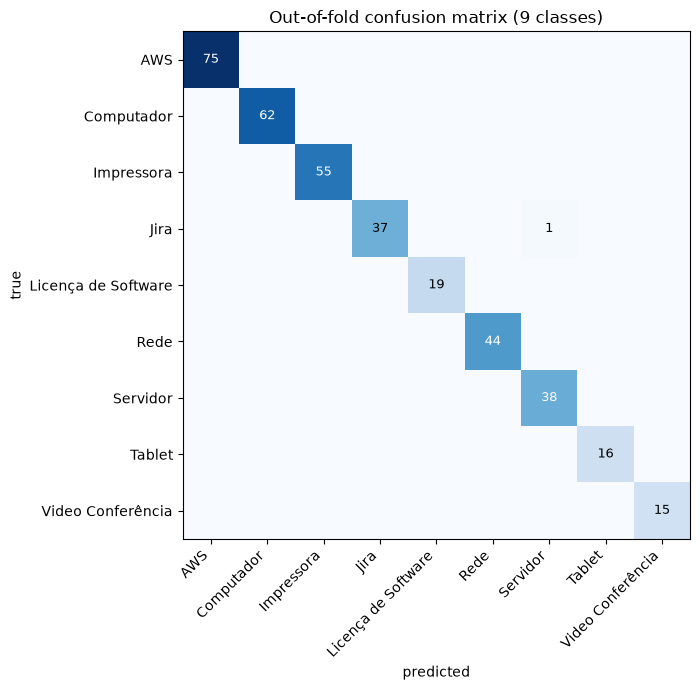

In [19]:
oof_proba = cross_val_predict(make_model(BEST_C), X_in, y_in, cv=cv, method="predict_proba")
oof_pred = np.array(CLASSES)[oof_proba.argmax(axis=1)]

print(classification_report(y_in, oof_pred, labels=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_in, oof_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set(xlabel="predicted", ylabel="true", title=f"Out-of-fold confusion matrix ({len(CLASSES)} classes)")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
plt.tight_layout()
plt.savefig("images/classification_confusion_matrix.png", dpi=300)
plt.show()

## Rejection rule

A ticket is accepted when the highest class probability pass a threshold; otherwise it is classify as `Other`. Two populations decide the threshold:

- **In-domain** tickets, scored out-of-fold: their max-probability should stay *above* the threshold (coverage).
- **`Other`** tickets, scored by a model trained on all in-domain data (they were never seen): their max-probability should fall *below* it (rejection).

The threshold maximises the balanced rate `(in-domain accepted + Other rejected) / 2`, so neither side dominates. The two distributions overlap - some noise tickets genuinely read like a class - so no threshold separates them fully; the plot shows the trade-off being made.

REJECT_THRESHOLD = 0.915
  in-domain accepted   89.5%   accuracy on accepted 100.0%
  Other rejected       95.5%

max-probability: in-domain median 0.96, Other median 0.48


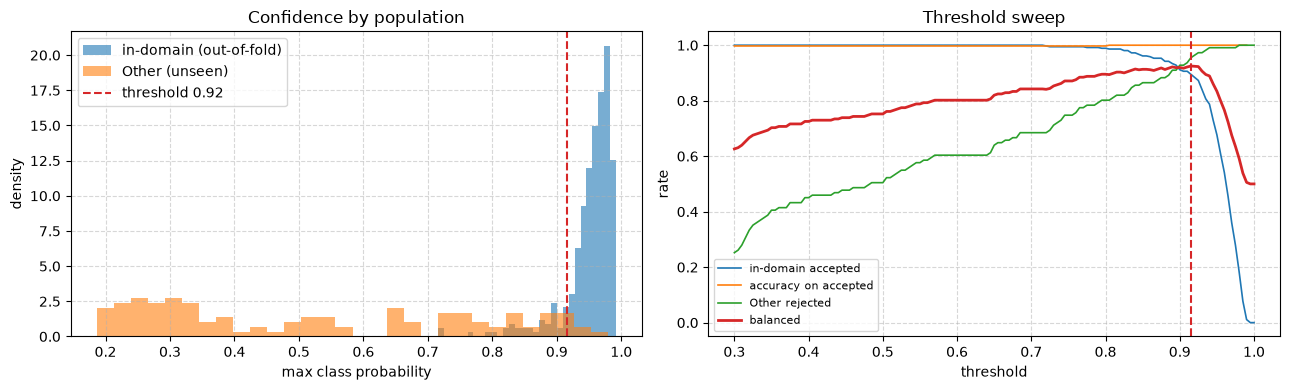

In [20]:
full_model = make_model(BEST_C).fit(X_in, y_in)
assert list(full_model.classes_) == CLASSES

conf_in = oof_proba.max(axis=1)
conf_other = full_model.predict_proba(X_other).max(axis=1)

sweep = rejection_sweep(conf_in, conf_other)
sweep["accuracy on accepted"] = [
    (oof_pred[conf_in >= t] == y_in[conf_in >= t]).mean() if (conf_in >= t).any() else np.nan
    for t in sweep.index]

REJECT_THRESHOLD = float(sweep["balanced"].idxmax())
chosen = sweep.loc[REJECT_THRESHOLD]
print(f"REJECT_THRESHOLD = {REJECT_THRESHOLD:.3f}")
print(f"  in-domain accepted   {chosen['in-domain accepted']:.1%}   "
      f"accuracy on accepted {chosen['accuracy on accepted']:.1%}")
print(f"  Other rejected       {chosen['Other rejected']:.1%}")
print(f"\nmax-probability: in-domain median {np.median(conf_in):.2f}, Other median {np.median(conf_other):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(conf_in, bins=30, alpha=.6, density=True, label="in-domain (out-of-fold)")
axes[0].hist(conf_other, bins=30, alpha=.6, density=True, label="Other (unseen)")
axes[0].axvline(REJECT_THRESHOLD, ls="--", color="tab:red", label=f"threshold {REJECT_THRESHOLD:.2f}")
axes[0].set(xlabel="max class probability", ylabel="density", title="Confidence by population")
axes[0].legend()
for col in ["in-domain accepted", "accuracy on accepted", "Other rejected", "balanced"]:
    axes[1].plot(sweep.index, sweep[col], label=col, lw=2 if col == "balanced" else 1.2)
axes[1].axvline(REJECT_THRESHOLD, ls="--", color="tab:red")
axes[1].set(xlabel="threshold", ylabel="rate", title="Threshold sweep")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(linestyle="--", alpha=.5)
plt.tight_layout()
plt.savefig("images/classification_rejection_threshold.png", dpi=300)
plt.show()

End-to-end view: out-of-fold predictions **with** the rejection rule, on every ticket. The `Other`
column now counts a genuine outcome (sent to a human), not a learned class.

In [30]:
def apply_rejection(proba, threshold=None):
    threshold = REJECT_THRESHOLD if threshold is None else threshold
    labels = np.array(CLASSES)[proba.argmax(axis=1)].astype(object)
    labels[proba.max(axis=1) < threshold] = OTHER_LABEL
    return labels


pred_all = np.empty(len(tickets_df), dtype=object)
pred_all[in_domain] = apply_rejection(oof_proba)
pred_all[~in_domain] = apply_rejection(full_model.predict_proba(X_other))

ALL_LABELS = CLASSES + [OTHER_LABEL]
print(classification_report(y, pred_all, labels=ALL_LABELS, digits=3, zero_division=0))

routing = pd.crosstab(pd.Series(y, name="true"), pd.Series(pred_all, name="predicted")).reindex(
    index=ALL_LABELS, columns=ALL_LABELS, fill_value=0)
routing

                     precision    recall  f1-score   support

                AWS      0.986     0.960     0.973        75
         Computador      1.000     0.839     0.912        62
         Impressora      0.981     0.945     0.963        55
               Jira      1.000     0.947     0.973        38
Licença de Software      0.824     0.737     0.778        19
               Rede      1.000     0.977     0.989        44
           Servidor      1.000     0.763     0.866        38
             Tablet      1.000     0.812     0.897        16
  Video Conferência      1.000     0.867     0.929        15
              Other      0.736     0.955     0.831       111

           accuracy                          0.909       473
          macro avg      0.953     0.880     0.911       473
       weighted avg      0.927     0.909     0.912       473



predicted,AWS,Computador,Impressora,Jira,Licença de Software,Rede,Servidor,Tablet,Video Conferência,Other
true,,,,,,,,,,
AWS,72,0,0,0,0,0,0,0,0,3
Computador,0,52,0,0,0,0,0,0,0,10
Impressora,0,0,52,0,0,0,0,0,0,3
Jira,0,0,0,36,0,0,0,0,0,2
Licença de Software,0,0,0,0,14,0,0,0,0,5
Rede,0,0,0,0,0,43,0,0,0,1
Servidor,0,0,0,0,0,0,29,0,0,9
Tablet,0,0,0,0,0,0,0,13,0,3
Video Conferência,0,0,0,0,0,0,0,0,13,2


## Save the model and inference function

The bundle carries everything inference needs: the encoder name and prefix, the class list, the fitted
model and the threshold. `classify_ticket` is the single entry point for new tickets: it cleans the text
with `ticket_cleaning.clean_ticket`, embeds it with the same encoder (on the GPU) and applies the
rejection rule.

In [39]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "embedding_model": EMBEDDING_MODEL,
    "embedding_prefix": EMBEDDING_PREFIX,
    "classes": CLASSES,
    "other_label": OTHER_LABEL,
    "reject_threshold": REJECT_THRESHOLD,
    "model": full_model,
}, MODEL_PATH)
print(f"saved -> {MODEL_PATH}")


def classify_ticket(subject, body, threshold=None):
    """Route one ticket: returns (label, confidence). Label is Other when confidence < threshold."""
    threshold = REJECT_THRESHOLD if threshold is None else threshold
    text = clean_ticket(subject, body)
    vector = get_encoder().encode([EMBEDDING_PREFIX + text], normalize_embeddings=True)
    proba = full_model.predict_proba(vector)[0]
    label, confidence = CLASSES[proba.argmax()], float(proba.max())
    return (label if confidence >= threshold else OTHER_LABEL), confidence


examples = [
    ("Roteador reiniciando", "O ISR4331 reinicia sozinho várias vezes por dia e derruba a rede do escritório."),
    ("Fatura AWS", "Recebi uma cobrança inesperada na conta AWS deste mês e preciso de esclarecimento."),
    ("Impressora não imprime por problema no Wi-Fi", "A DeskJet não aparece mais no Wi-Fi depois que troquei o roteador."),
    ("Problema com impressora", "Impressora não funciona desde que atualizei o driver."),
    ("Erro no Jira", "Não consigo anexar arquivos aos tickets desde a atualização para a versão 8.20."),
    ("Pedido de orçamento", "Gostaria de um orçamento para 20 licenças de um software de RH."),
]
started = time.perf_counter()
for subject, body in examples:
    label, confidence = classify_ticket(subject, body, threshold=0.5)
    print(f"{confidence:.2f}  {label:<52} {subject}")
print(f"\n{len(examples)} tickets classified in {time.perf_counter() - started:.1f}s on {DEVICE} (includes model load)")

saved -> models\ticket_classifier.joblib
0.94  Rede                                                 Roteador reiniciando
0.95  AWS                                                  Fatura AWS
0.89  Impressora                                           Impressora não imprime por problema no Wi-Fi
0.74  Impressora                                           Problema com impressora
0.99  Jira                                                 Erro no Jira
0.47  Other                                                Pedido de orçamento

6 tickets classified in 0.3s on cuda (includes model load)
